# DINOv2 on Dollar Street: Is the Geographic/Income Bias in the Backbone or the Linear Probe?

**Testing Hypothesis 3** from the "Genuinely Testable Hypotheses" document.

DINOv2's own paper reports a 25.7-point accuracy drop on African vs. European images, and a
31.7-point drop for low- vs. high-income households, on the Dollar Street fairness benchmark —
and frames this as the backbone being "biased toward Western countries." But DINOv2's own
evaluation protocol only ever fits a **linear classifier on frozen features**; the backbone itself
is never fine-tuned. That leaves two very different possible causes bundled together in one number:

- **(a)** the self-supervised features genuinely don't encode enough information to tell
  underrepresented-region objects apart, or
- **(b)** the features are fine, but a class-balanced-but-not-region-balanced linear probe bakes
  regional/income skew into the decision boundary even though the underlying representation is
  unbiased.

This notebook isolates **(b)** without touching the DINOv2 backbone at all: we train two linear
probes on the *same frozen features* — one with standard class-balanced sampling, one with an
explicit region-and-income-stratified resample — and compare how much of the region/income
accuracy gap each one closes.

**Important scope note (stated up front, not buried in the limitations section):** this uses the
`nlphuji/dollar_street_test` Hugging Face mirror (1,600 images, object-`topics` labels, `region.id`
and `income` metadata), which is a genuine subset of the same Dollar Street dataset but is **not**
the exact ImageNet-mapped evaluation harness Meta used internally for the paper's headline numbers.
Treat this as a testable analogue that answers a narrower, well-posed question — not a literal
reproduction of the paper's 25.7-point figure.

In [1]:
# -- Install required packages --------------------------------------------
!pip install -q datasets transformers
print("Installed.")

Installed.


In [2]:
# -- Core imports -----------------------------------------------------------
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

from datasets import load_dataset
from transformers import AutoImageProcessor, AutoModel

import warnings
warnings.filterwarnings('ignore')

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on: {DEVICE.upper()}")

Running on: CUDA


## 1 -- Load Dollar Street and build the classification task

We keep only object classes (`topics[0]`) with enough images to support a train/test split, and record each image's world region and an income bucket for the fairness breakdown later.

In [3]:
print("Loading nlphuji/dollar_street_test ...")

# Newer `datasets` releases (v4+) dropped support for repos that still ship a Python loading
# script, and this repo hasn't been migrated -- load_dataset("nlphuji/dollar_street_test")
# fails with "RuntimeError: Dataset scripts are no longer supported". The fix is to bypass the
# script entirely and load the Hub's auto-converted Parquet shards directly (every dataset gets
# these regardless of whether the repo itself has a script).
try:
    ds = load_dataset("nlphuji/dollar_street_test")["test"]
except RuntimeError as e:
    if "Dataset scripts are no longer supported" not in str(e):
        raise
    print("  (loading script unsupported in this datasets version -- falling back to the "
          "auto-converted Parquet shards on the 'refs/convert/parquet' branch)")
    parquet_glob = "hf://datasets/nlphuji/dollar_street_test@refs/convert/parquet/TEST/**/*.parquet"
    ds_dict = load_dataset("parquet", data_files=parquet_glob)
    # the generic "parquet" loader always names the split "train" regardless of the source's
    # original split name, so just grab whichever single split came back
    ds = ds_dict[list(ds_dict.keys())[0]]

print(f"Loaded {len(ds)} images.")
print(ds.features)

Loading nlphuji/dollar_street_test ...


README.md:   0%|          | 0.00/737 [00:00<?, ?B/s]

dollar_street_test.py:   0%|          | 0.00/2.96k [00:00<?, ?B/s]

  (loading script unsupported in this datasets version -- falling back to the auto-converted Parquet shards on the 'refs/convert/parquet' branch)


TEST/partial-test/0000.parquet: reconstructing file:   0%|          |  0.00B /  649MB            

...

TEST/partial-test/0006.parquet: downloading bytes:           |  0.00B            

TEST/partial-test/0007.parquet: reconstructing file:   0%|          |  0.00B /  597MB            

TEST/partial-test/0007.parquet: downloading bytes:           |  0.00B            

Generating train split: 0 examples [00:00, ? examples/s]

Loaded 1600 images.
{'image': Image(mode=None, decode=True), 'id': Value('string'), 'country.id': Value('string'), 'country.name': Value('string'), 'region.id': Value('string'), 'type': Value('string'), 'imageRelPath': Value('string'), 'topics': List(Value('string')), 'place': Value('string'), 'income': Value('string'), 'imagenet_synonyms': List(Value('string')), 'imagenet_sysnet_id': List(Value('string')), 'image_name': Value('string')}


In [4]:
REGION_NAMES = {"af": "Africa", "am": "Americas", "as": "Asia", "eu": "Europe"}

def get_field(example, *candidates, default=None):
    '''Try several possible (possibly nested) field names -- HF dataset schemas sometimes
    flatten dotted columns into nested dicts depending on the loader version.'''
    for cand in candidates:
        if "." in cand:
            top, sub = cand.split(".", 1)
            if top in example and isinstance(example[top], dict) and sub in example[top]:
                return example[top][sub]
        if cand in example:
            return example[cand]
    return default

records = []
for i, ex in enumerate(ds):
    topics = get_field(ex, "topics", default=[])
    if not topics:
        continue
    label = topics[0]
    region_id = get_field(ex, "region.id", "region_id", "region", default="unknown")
    if isinstance(region_id, dict):
        region_id = region_id.get("id", "unknown")
    income_raw = get_field(ex, "income", default=None)
    try:
        income = float(income_raw)
    except (TypeError, ValueError):
        income = None
    if income is None:
        continue
    records.append({"idx": i, "label": label, "region_id": region_id, "income": income})

df = pd.DataFrame(records)
df["region"] = df["region_id"].map(REGION_NAMES).fillna("Unknown")
print(f"Usable images (valid topic + income + region): {len(df)}")
df.head()

Usable images (valid topic + income + region): 1600


,idx,label,region_id,income,region
0,0,tv,as,146.494165,Asia
1,1,tv,am,1098.831667,Americas
2,2,phone,as,96.000000,Asia
3,3,computer,am,3360.000000,Americas
4,4,bathroom/toilet,as,826.615810,Asia


In [5]:
# -- Keep only classes with enough images to support an 80/20 split ----------
MIN_PER_CLASS = 15
class_counts = df["label"].value_counts()
keep_classes = class_counts[class_counts >= MIN_PER_CLASS].index.tolist()
df = df[df["label"].isin(keep_classes)].reset_index(drop=True)

CLASS_NAMES = sorted(df["label"].unique().tolist())
CLASS_TO_ID = {c: i for i, c in enumerate(CLASS_NAMES)}
df["label_id"] = df["label"].map(CLASS_TO_ID)

print(f"Kept {len(CLASS_NAMES)} classes with >= {MIN_PER_CLASS} images: {CLASS_NAMES}")
print(f"Total usable images: {len(df)}")

# -- Income buckets: empirical tertiles (log-income), computed on this subset ----------------
df["log_income"] = np.log(df["income"].clip(lower=1.0))
q1, q2 = df["log_income"].quantile([1/3, 2/3])
def bucket_income(x):
    if x <= q1: return "low"
    if x <= q2: return "medium"
    return "high"
df["income_bucket"] = df["log_income"].apply(bucket_income)

print("\nRegion distribution:")
print(df["region"].value_counts())
print("\nIncome bucket distribution:")
print(df["income_bucket"].value_counts())
print("\nRegion x income_bucket cross-tab (small cells are expected -- flagged later):")
print(pd.crosstab(df["region"], df["income_bucket"]))

Kept 52 classes with >= 15 images: ['armchair', 'bathroom/toilet', 'bed', 'bike', 'books', 'ceiling', 'cleaning equipment', 'computer', 'cooking pots', 'cooking utensils', 'couch', 'cups/mugs/glasses', 'cutlery', 'dish racks', 'dish washing brush/cloth', 'dish washing soap', 'drinking water', 'everyday shoes', 'home', 'kitchen sink', 'light source in kitchen', 'light source in livingroom', 'lock on front door', 'medication', 'mosquito protection', 'paper', 'pen/pencils', 'phone', 'place where eating dinner', 'plate of food', 'plates', 'refrigerator', 'roof', 'salt', 'shower', 'soap for hands and body', 'social drink', 'source of cool', 'stove/hob', 'street detail', 'street view', 'switch on/off', 'table with food', 'toilet', 'toilet paper', 'tools', 'toys', 'trash/waste', 'tv', 'visit', 'wardrobe', 'washing clothes/cleaning']
Total usable images: 1351

Region distribution:
region
Asia        653
Americas    267
Africa      257
Europe      174
Name: count, dtype: int64

Income bucket di

---

## 2 -- Extract frozen DINOv2 features for every kept image

Same model choice as the `DINOv2_FewShot` notebook (`facebook/dinov2-small`), so results are directly comparable to the CIFAR-10 few-shot numbers already in the report.

In [6]:
MODEL_NAME = "facebook/dinov2-small"
print(f"Loading {MODEL_NAME} ...")
dino_processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
dino_model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
dino_model.eval()
EMBED_DIM = dino_model.config.hidden_size
print(f"Loaded. Embedding dim: {EMBED_DIM}")

Loading facebook/dinov2-small ...


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Loaded. Embedding dim: 384


In [7]:
@torch.no_grad()
def extract_features(dataset, row_indices):
    feats = []
    for pos, row_idx in enumerate(row_indices):
        pil_img = dataset[int(row_idx)]["image"].convert("RGB")
        inputs = dino_processor(images=pil_img, return_tensors="pt").to(DEVICE)
        out = dino_model(**inputs)
        cls_feat = out.last_hidden_state[:, 0, :]
        cls_feat = F.normalize(cls_feat, dim=-1)
        feats.append(cls_feat.cpu())
        if (pos + 1) % 200 == 0:
            print(f"  extracted {pos + 1}/{len(row_indices)}")
    return torch.cat(feats, dim=0)

print(f"Extracting DINOv2 features for {len(df)} images (this is the slow cell, run once)...")
all_features = extract_features(ds, df["idx"].tolist())
print(f"Done. Feature matrix: {all_features.shape}")

Extracting DINOv2 features for 1351 images (this is the slow cell, run once)...
  extracted 200/1351
  extracted 400/1351
  extracted 600/1351
  extracted 800/1351
  extracted 1000/1351
  extracted 1200/1351
Done. Feature matrix: torch.Size([1351, 384])


---

## 3 -- Stratified train/test split (by class)

80/20 split, stratified so every kept class appears in both train and test.

In [8]:
def stratified_split(df, test_frac=0.2, seed=0):
    rng = np.random.RandomState(seed)
    train_pos, test_pos = [], []
    for label_id, group in df.groupby("label_id"):
        positions = group.index.to_numpy()
        rng.shuffle(positions)
        n_test = max(1, int(round(len(positions) * test_frac)))
        test_pos.extend(positions[:n_test].tolist())
        train_pos.extend(positions[n_test:].tolist())
    return np.array(train_pos), np.array(test_pos)

train_pos, test_pos = stratified_split(df)
print(f"Train: {len(train_pos)} images | Test: {len(test_pos)} images")

X_train_full = all_features[train_pos]
y_train_full = torch.tensor(df.loc[train_pos, "label_id"].to_numpy())
X_test = all_features[test_pos].to(DEVICE)
y_test = torch.tensor(df.loc[test_pos, "label_id"].to_numpy()).to(DEVICE)

train_df = df.loc[train_pos].reset_index(drop=True)
test_df = df.loc[test_pos].reset_index(drop=True)

Train: 1081 images | Test: 270 images


---

## 4 -- Probe A: standard linear probe (natural class-balanced-only sampling)

This mirrors what DINOv2's own paper does: fit a linear head on frozen features with no explicit region/income rebalancing.

In [9]:
class LinearProbe(torch.nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc = torch.nn.Linear(input_dim, num_classes)
    def forward(self, x):
        return self.fc(x)


def train_linear_probe(X, y, num_classes, epochs=60, lr=1e-3, batch_size=64, weight_decay=1e-4):
    probe = LinearProbe(X.shape[1], num_classes).to(DEVICE)
    optimizer = torch.optim.Adam(probe.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = torch.nn.CrossEntropyLoss()
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X.to(DEVICE), y.to(DEVICE)),
        batch_size=batch_size, shuffle=True)
    probe.train()
    for epoch in range(epochs):
        for bx, by in loader:
            optimizer.zero_grad()
            loss = criterion(probe(bx), by)
            loss.backward()
            optimizer.step()
    probe.eval()
    return probe


probe_A = train_linear_probe(X_train_full, y_train_full, num_classes=len(CLASS_NAMES))
print("Probe A (standard sampling) trained.")

Probe A (standard sampling) trained.


---

## 5 -- Probe B: region + income balanced resample

Within each class, we oversample (with replacement) so that every observed (region, income-bucket) combination is represented close to equally, up to a capped multiplier so no single rare cell explodes the effective training set size.

In [10]:
def balanced_resample_indices(sub_df, group_cols=("region", "income_bucket"), max_multiplier=5, seed=0):
    '''Returns a list of positions (into sub_df) resampled so groups within each class are
    balanced, capped at max_multiplier x the group's original count to avoid extreme duplication.'''
    rng = np.random.RandomState(seed)
    resampled = []
    for label_id, class_group in sub_df.groupby("label_id"):
        group_key = class_group[list(group_cols)].astype(str).agg("_".join, axis=1)
        counts = group_key.value_counts()
        target = counts.max()
        for key, count in counts.items():
            positions = class_group.index[group_key == key].to_numpy()
            n_target = min(target, count * max_multiplier)
            chosen = rng.choice(positions, size=int(n_target), replace=True)
            resampled.extend(chosen.tolist())
    return resampled


balanced_positions = balanced_resample_indices(train_df)
print(f"Balanced resample: {len(train_df)} -> {len(balanced_positions)} training examples "
      f"({len(balanced_positions) / len(train_df):.2f}x)")

# positions here are into train_df / X_train_full (same index space)
X_train_balanced = X_train_full[balanced_positions]
y_train_balanced = y_train_full[balanced_positions]

probe_B = train_linear_probe(X_train_balanced, y_train_balanced, num_classes=len(CLASS_NAMES))
print("Probe B (region+income balanced resample) trained.")

Balanced resample: 1081 -> 2136 training examples (1.98x)
Probe B (region+income balanced resample) trained.


---

## 6 -- Evaluate both probes, broken down by region and income bucket

In [11]:
@torch.no_grad()
def evaluate_breakdown(probe, X, y, meta_df, group_col):
    preds = probe(X).argmax(dim=1).cpu().numpy()
    y_np = y.cpu().numpy()
    correct = (preds == y_np)
    overall = correct.mean() * 100

    breakdown = {}
    for group_val, sub in meta_df.groupby(group_col):
        mask = sub.index.to_numpy()
        if len(mask) == 0:
            continue
        breakdown[group_val] = correct[mask].mean() * 100
    return overall, breakdown


def summarize(probe, name):
    overall, region_acc = evaluate_breakdown(probe, X_test, y_test, test_df, "region")
    _, income_acc = evaluate_breakdown(probe, X_test, y_test, test_df, "income_bucket")

    region_gap = max(region_acc.values()) - min(region_acc.values()) if len(region_acc) > 1 else float('nan')
    income_gap = max(income_acc.values()) - min(income_acc.values()) if len(income_acc) > 1 else float('nan')

    print(f"\n=== {name} ===")
    print(f"Overall test accuracy: {overall:.1f}%")
    print("By region:")
    for r, a in sorted(region_acc.items(), key=lambda x: -x[1]):
        n = (test_df['region'] == r).sum()
        print(f"    {r:>10}: {a:5.1f}%  (n={n})")
    print(f"  Region gap (max-min): {region_gap:.1f} pts")
    print("By income bucket:")
    for b, a in sorted(income_acc.items(), key=lambda x: -x[1]):
        n = (test_df['income_bucket'] == b).sum()
        print(f"    {b:>10}: {a:5.1f}%  (n={n})")
    print(f"  Income gap (max-min): {income_gap:.1f} pts")

    return {"overall": overall, "region_acc": region_acc, "income_acc": income_acc,
            "region_gap": region_gap, "income_gap": income_gap}


results_A = summarize(probe_A, "Probe A: standard sampling")
results_B = summarize(probe_B, "Probe B: region+income balanced resample")


=== Probe A: standard sampling ===
Overall test accuracy: 65.6%
By region:
      Americas:  73.9%  (n=46)
          Asia:  66.4%  (n=125)
        Europe:  65.9%  (n=41)
        Africa:  56.9%  (n=58)
  Region gap (max-min): 17.0 pts
By income bucket:
          high:  72.3%  (n=101)
        medium:  67.4%  (n=89)
           low:  55.0%  (n=80)
  Income gap (max-min): 17.3 pts

=== Probe B: region+income balanced resample ===
Overall test accuracy: 63.3%
By region:
      Americas:  71.7%  (n=46)
          Asia:  64.0%  (n=125)
        Europe:  63.4%  (n=41)
        Africa:  55.2%  (n=58)
  Region gap (max-min): 16.6 pts
By income bucket:
          high:  73.3%  (n=101)
        medium:  68.5%  (n=89)
           low:  45.0%  (n=80)
  Income gap (max-min): 28.3 pts


In [12]:
# -- Gap-closing summary -----------------------------------------------------
def pct_closed(before, after):
    if before == 0:
        return float('nan')
    return (before - after) / before * 100

region_closed = pct_closed(results_A["region_gap"], results_B["region_gap"])
income_closed = pct_closed(results_A["income_gap"], results_B["income_gap"])

print(f"{'':>22} {'Probe A (standard)':>20} {'Probe B (balanced)':>20} {'% of gap closed':>18}")
print("-" * 84)
print(f"{'Overall accuracy':>22} {results_A['overall']:>19.1f}% {results_B['overall']:>19.1f}% {'--':>18}")
print(f"{'Region gap':>22} {results_A['region_gap']:>19.1f} {results_B['region_gap']:>19.1f} {region_closed:>17.1f}%")
print(f"{'Income gap':>22} {results_A['income_gap']:>19.1f} {results_B['income_gap']:>19.1f} {income_closed:>17.1f}%")

                         Probe A (standard)   Probe B (balanced)    % of gap closed
------------------------------------------------------------------------------------
      Overall accuracy                65.6%                63.3%                 --
            Region gap                17.0                16.6               2.6%
            Income gap                17.3                28.3             -63.6%


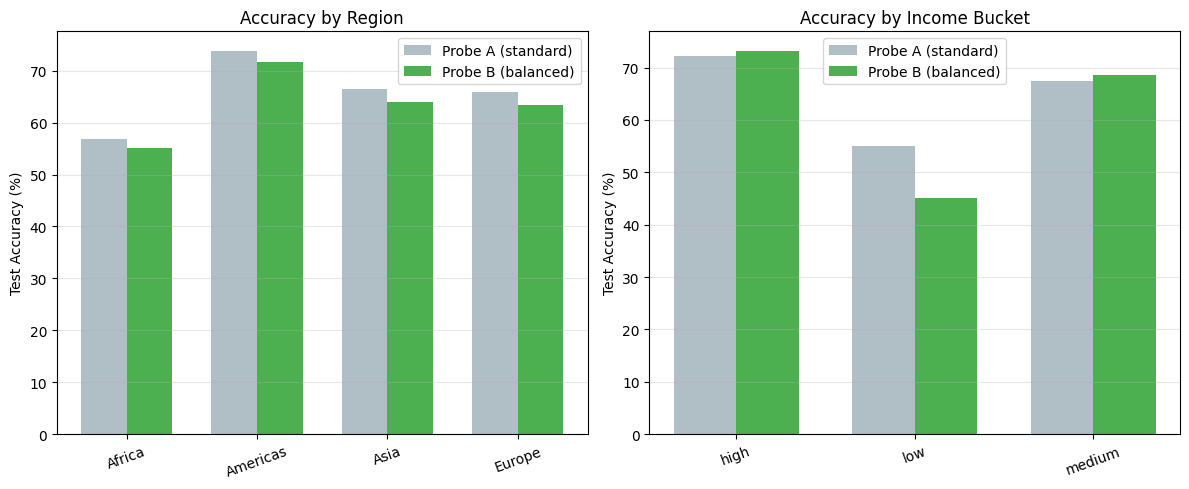

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (title, acc_a, acc_b) in zip(
    axes,
    [("Accuracy by Region", results_A["region_acc"], results_B["region_acc"]),
     ("Accuracy by Income Bucket", results_A["income_acc"], results_B["income_acc"])]
):
    keys = sorted(set(acc_a.keys()) | set(acc_b.keys()))
    x = np.arange(len(keys))
    width = 0.35
    ax.bar(x - width/2, [acc_a.get(k, 0) for k in keys], width, label='Probe A (standard)', color='#B0BEC5')
    ax.bar(x + width/2, [acc_b.get(k, 0) for k in keys], width, label='Probe B (balanced)', color='#4CAF50')
    ax.set_xticks(x)
    ax.set_xticklabels(keys, rotation=20)
    ax.set_ylabel('Test Accuracy (%)')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('dinov2_bias_probe_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 7 -- Interpreting the result (per Hypothesis 3's own falsification criterion)

- **If Probe B closes most of the region/income gap** (high "% of gap closed" above) while using the
  *exact same frozen DINOv2 features* as Probe A: this supports the hypothesis that a meaningful part
  of the reported bias comes from **imbalanced linear-probe training**, not from the backbone's
  self-supervised representation itself -- a cheaper, more actionable finding than "the backbone
  is biased," since it implies fairness gains are available without retraining a foundation model.

- **If the gap barely moves even with a fully balanced resample:** report this as a genuine negative
  result, not a failed experiment. It means the frozen features don't linearly separate
  underrepresented-region/income classes well, which points back toward the backbone/pretraining-data
  explanation this notebook was designed to help rule in or out. Say so plainly in the writeup rather
  than only reporting a positive result.

**What this experiment does *not* claim:** a linear probe can only recover what's already linearly
present in the frozen features. A small gap-reduction here doesn't prove the backbone is fully
unbiased at some deeper, non-linear level -- it answers the narrower, well-posed question of whether
*this specific gap number, under DINOv2's own published evaluation protocol (linear probe on frozen
features)*, is attributable to classifier-training imbalance vs. feature quality. That's the honest
scope Hypothesis 3 was written to have.

**Caveats to state alongside any numbers you report:**
- Some (region, income-bucket) cells are small (see the cross-tab in Section 1) -- the balanced
  resample's oversampling multiplier is capped at 5x specifically to avoid a handful of images
  dominating Probe B's training signal; report this cap alongside your results.
- This uses `nlphuji/dollar_street_test`'s `topics` labels directly rather than DINOv2's paper's
  ImageNet-mapped taxonomy, so absolute accuracy numbers are not comparable to the paper's; only the
  **within-notebook gap comparison (Probe A vs. Probe B)** is the intended takeaway.

**Suggested use in the report:** this extends Chapter 7 (Ethical, Social, and Environmental
Considerations) beyond the current one-paragraph acknowledgment of VLM bias, and gives Future Work
(9.2) a concrete, already-executed first step toward the fairness angle of few-shot foundation-model
deployment, rather than only listing it as a direction.

In [14]:
print("Region x income_bucket cross-tab (test split only, for reference):")
print(pd.crosstab(test_df["region"], test_df["income_bucket"]))

print("\nRegion x income_bucket cross-tab (full kept dataset):")
crosstab_full = pd.crosstab(df["region"], df["income_bucket"])
print(crosstab_full)

# Cramer's V as a simple, self-contained confound-strength check (0 = independent, 1 = fully confounded)
chi2 = 0.0
row_totals = crosstab_full.sum(axis=1)
col_totals = crosstab_full.sum(axis=0)
n_total = crosstab_full.values.sum()
for r in crosstab_full.index:
    for c in crosstab_full.columns:
        observed = crosstab_full.loc[r, c]
        expected = row_totals[r] * col_totals[c] / n_total
        if expected > 0:
            chi2 += (observed - expected) ** 2 / expected
n_rows, n_cols = crosstab_full.shape
cramers_v = np.sqrt(chi2 / (n_total * (min(n_rows, n_cols) - 1)))
print(f"\nCramer's V (region vs. income_bucket): {cramers_v:.2f}  "
      f"({'strongly confounded' if cramers_v > 0.3 else 'weakly/moderately associated'} "
      f"-- 0 = independent, 1 = fully determined by each other)")

Region x income_bucket cross-tab (test split only, for reference):
income_bucket  high  low  medium
region                          
Africa            7   37      14
Americas         24    5      17
Asia             39   36      50
Europe           31    2       8

Region x income_bucket cross-tab (full kept dataset):
income_bucket  high  low  medium
region                          
Africa           25  174      58
Americas        108   47     112
Asia            175  232     246
Europe          143    3      28

Cramer's V (region vs. income_bucket): 0.37  (strongly confounded -- 0 = independent, 1 = fully determined by each other)


In [15]:
def balanced_resample_indices(sub_df, group_cols, max_multiplier=5, seed=0):
    '''Returns a list of positions (into sub_df) resampled so groups within each class are
    balanced, capped at max_multiplier x the group's original count to avoid extreme duplication.'''
    rng = np.random.RandomState(seed)
    resampled = []
    for label_id, class_group in sub_df.groupby("label_id"):
        group_key = class_group[list(group_cols)].astype(str).agg("_".join, axis=1)
        counts = group_key.value_counts()
        target = counts.max()
        for key, count in counts.items():
            positions = class_group.index[group_key == key].to_numpy()
            n_target = min(target, count * max_multiplier)
            chosen = rng.choice(positions, size=int(n_target), replace=True)
            resampled.extend(chosen.tolist())
    return resampled


def resample_and_train(group_cols, label):
    positions = balanced_resample_indices(train_df, group_cols=group_cols)
    print(f"{label}: {len(train_df)} -> {len(positions)} training examples "
          f"({len(positions) / len(train_df):.2f}x)")
    X_bal = X_train_full[positions]
    y_bal = y_train_full[positions]
    probe = train_linear_probe(X_bal, y_bal, num_classes=len(CLASS_NAMES))
    return probe


probe_B = resample_and_train(("region", "income_bucket"), "Probe B (joint region+income balanced)")
probe_C = resample_and_train(("region",), "Probe C (region-only balanced)")
probe_D = resample_and_train(("income_bucket",), "Probe D (income-only balanced)")
print("All three balanced probes trained.")

Probe B (joint region+income balanced): 1081 -> 2136 training examples (1.98x)
Probe C (region-only balanced): 1081 -> 1925 training examples (1.78x)
Probe D (income-only balanced): 1081 -> 1479 training examples (1.37x)
All three balanced probes trained.


In [16]:
@torch.no_grad()
def evaluate_breakdown(probe, X, y, meta_df, group_col):
    preds = probe(X).argmax(dim=1).cpu().numpy()
    y_np = y.cpu().numpy()
    correct = (preds == y_np)
    overall = correct.mean() * 100

    breakdown = {}
    for group_val, sub in meta_df.groupby(group_col):
        mask = sub.index.to_numpy()
        if len(mask) == 0:
            continue
        breakdown[group_val] = correct[mask].mean() * 100
    return overall, breakdown


def summarize(probe, name):
    overall, region_acc = evaluate_breakdown(probe, X_test, y_test, test_df, "region")
    _, income_acc = evaluate_breakdown(probe, X_test, y_test, test_df, "income_bucket")

    region_gap = max(region_acc.values()) - min(region_acc.values()) if len(region_acc) > 1 else float('nan')
    income_gap = max(income_acc.values()) - min(income_acc.values()) if len(income_acc) > 1 else float('nan')

    print(f"\n=== {name} ===")
    print(f"Overall test accuracy: {overall:.1f}%")
    print("By region:")
    for r, a in sorted(region_acc.items(), key=lambda x: -x[1]):
        n = (test_df['region'] == r).sum()
        print(f"    {r:>10}: {a:5.1f}%  (n={n})")
    print(f"  Region gap (max-min): {region_gap:.1f} pts")
    print("By income bucket:")
    for b, a in sorted(income_acc.items(), key=lambda x: -x[1]):
        n = (test_df['income_bucket'] == b).sum()
        print(f"    {b:>10}: {a:5.1f}%  (n={n})")
    print(f"  Income gap (max-min): {income_gap:.1f} pts")

    return {"overall": overall, "region_acc": region_acc, "income_acc": income_acc,
            "region_gap": region_gap, "income_gap": income_gap}


results_A = summarize(probe_A, "Probe A: standard sampling")
results_B = summarize(probe_B, "Probe B: joint region+income balanced")
results_C = summarize(probe_C, "Probe C: region-only balanced")
results_D = summarize(probe_D, "Probe D: income-only balanced")


=== Probe A: standard sampling ===
Overall test accuracy: 65.6%
By region:
      Americas:  73.9%  (n=46)
          Asia:  66.4%  (n=125)
        Europe:  65.9%  (n=41)
        Africa:  56.9%  (n=58)
  Region gap (max-min): 17.0 pts
By income bucket:
          high:  72.3%  (n=101)
        medium:  67.4%  (n=89)
           low:  55.0%  (n=80)
  Income gap (max-min): 17.3 pts

=== Probe B: joint region+income balanced ===
Overall test accuracy: 63.0%
By region:
      Americas:  71.7%  (n=46)
          Asia:  64.0%  (n=125)
        Europe:  63.4%  (n=41)
        Africa:  53.4%  (n=58)
  Region gap (max-min): 18.3 pts
By income bucket:
          high:  73.3%  (n=101)
        medium:  67.4%  (n=89)
           low:  45.0%  (n=80)
  Income gap (max-min): 28.3 pts

=== Probe C: region-only balanced ===
Overall test accuracy: 63.3%
By region:
      Americas:  69.6%  (n=46)
        Africa:  67.2%  (n=58)
        Europe:  63.4%  (n=41)
          Asia:  59.2%  (n=125)
  Region gap (max-min): 10.

In [17]:
# -- Gap-closing summary across all three balancing strategies ---------------
def pct_closed(before, after):
    if before == 0:
        return float('nan')
    return (before - after) / before * 100

rows = [
    ("Probe B (joint)",        results_B),
    ("Probe C (region-only)",  results_C),
    ("Probe D (income-only)",  results_D),
]

print(f"{'Probe':>22} {'Region gap':>12} {'% closed':>10} {'Income gap':>12} {'% closed':>10}")
print("-" * 70)
print(f"{'A: standard (baseline)':>22} {results_A['region_gap']:>11.1f} {'--':>10} "
      f"{results_A['income_gap']:>11.1f} {'--':>10}")
for name, res in rows:
    rc = pct_closed(results_A["region_gap"], res["region_gap"])
    ic = pct_closed(results_A["income_gap"], res["income_gap"])
    print(f"{name:>22} {res['region_gap']:>11.1f} {rc:>9.1f}% {res['income_gap']:>11.1f} {ic:>9.1f}%")

                 Probe   Region gap   % closed   Income gap   % closed
----------------------------------------------------------------------
A: standard (baseline)        17.0         --        17.3         --
       Probe B (joint)        18.3      -7.5%        28.3     -63.6%
 Probe C (region-only)        10.4      39.1%        18.1      -4.5%
 Probe D (income-only)        19.6     -15.0%        23.8     -37.7%


## 8 -- Probe E/F: weighted-loss variants (same target ratios, no physical duplication)

Probes B and D balance groups by **physically duplicating rows** (`balanced_resample_indices`),
capped at `max_multiplier x` the group's original count. When a group is as thin as Europe's
low-income slice (n=3 in the whole dataset), that duplication means the *same 3 feature vectors*
get repeated up to 5x *within every epoch*, which lets the probe memorize those specific vectors
rather than learn a generalizable decision boundary from real diversity.

To isolate "duplication-induced overfitting" from "income imbalance is genuinely hard to correct",
we re-run the income-only and joint corrections as a **weighted loss** instead: every image is seen
by the optimizer exactly once per epoch, but its contribution to the loss is scaled by the *same*
target ratio (`min(target, count * max_multiplier) / count`) that the duplication approach used to
decide how many physical copies to create. This keeps the correction strength identical to Probes
B/D -- the only thing that changes is whether the extra weight comes from literal copies or from a
larger gradient contribution.

- If the income/joint backfire **disappears** here, that confirms duplication-as-mechanism was the
  real culprit -- income bias was correctable, we just used the wrong tool.
- If the backfire **persists**, that's a materially different and stronger claim: income bias
  resists a properly-implemented correction too, suggesting it's tangled deeper into the frozen
  features than the region signal is.


In [18]:
def compute_sample_weights(sub_df, group_cols, max_multiplier=5):
    '''Per-example loss weights that encode the SAME target ratio balanced_resample_indices uses
    (min(target, count * max_multiplier) / count), but applied continuously instead of via
    physical row duplication. Every original row is used exactly once per epoch.'''
    weights = np.ones(len(sub_df))
    for label_id, class_group in sub_df.groupby("label_id"):
        group_key = class_group[list(group_cols)].astype(str).agg("_".join, axis=1)
        counts = group_key.value_counts()
        target = counts.max()
        for key, count in counts.items():
            n_target = min(target, count * max_multiplier)
            w = n_target / count
            idx = class_group.index[group_key == key].to_numpy()
            weights[idx] = w
    return weights


In [19]:
def train_linear_probe_weighted(X, y, sample_weights, num_classes, epochs=60, lr=1e-3,
                                 batch_size=64, weight_decay=1e-4):
    probe = LinearProbe(X.shape[1], num_classes).to(DEVICE)
    optimizer = torch.optim.Adam(probe.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = torch.nn.CrossEntropyLoss(reduction='none')
    w_tensor = torch.as_tensor(sample_weights, dtype=torch.float32)
    dataset = torch.utils.data.TensorDataset(X.to(DEVICE), y.to(DEVICE), w_tensor.to(DEVICE))
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    probe.train()
    for epoch in range(epochs):
        for bx, by, bw in loader:
            optimizer.zero_grad()
            per_example_loss = criterion(probe(bx), by)
            loss = (per_example_loss * bw).sum() / bw.sum()
            loss.backward()
            optimizer.step()
    probe.eval()
    return probe


weights_income = compute_sample_weights(train_df, group_cols=("income_bucket",))
weights_joint = compute_sample_weights(train_df, group_cols=("region", "income_bucket"))

probe_D_weighted = train_linear_probe_weighted(
    X_train_full, y_train_full, weights_income, num_classes=len(CLASS_NAMES))
print("Probe D-weighted (income-only, weighted loss) trained.")

probe_B_weighted = train_linear_probe_weighted(
    X_train_full, y_train_full, weights_joint, num_classes=len(CLASS_NAMES))
print("Probe B-weighted (joint, weighted loss) trained.")


Probe D-weighted (income-only, weighted loss) trained.
Probe B-weighted (joint, weighted loss) trained.


In [20]:
results_D_weighted = summarize(probe_D_weighted, "Probe D-weighted: income-only (weighted loss, no duplication)")
results_B_weighted = summarize(probe_B_weighted, "Probe B-weighted: joint (weighted loss, no duplication)")



=== Probe D-weighted: income-only (weighted loss, no duplication) ===
Overall test accuracy: 65.9%
By region:
      Americas:  73.9%  (n=46)
          Asia:  68.0%  (n=125)
        Europe:  63.4%  (n=41)
        Africa:  56.9%  (n=58)
  Region gap (max-min): 17.0 pts
By income bucket:
          high:  73.3%  (n=101)
        medium:  69.7%  (n=89)
           low:  52.5%  (n=80)
  Income gap (max-min): 20.8 pts

=== Probe B-weighted: joint (weighted loss, no duplication) ===
Overall test accuracy: 63.7%
By region:
      Americas:  67.4%  (n=46)
          Asia:  66.4%  (n=125)
        Europe:  61.0%  (n=41)
        Africa:  56.9%  (n=58)
  Region gap (max-min): 10.5 pts
By income bucket:
          high:  70.3%  (n=101)
        medium:  68.5%  (n=89)
           low:  50.0%  (n=80)
  Income gap (max-min): 20.3 pts


In [21]:
# -- Duplication vs. weighted-loss comparison, same target ratios ------------
def pct_closed(before, after):
    if before == 0:
        return float('nan')
    return (before - after) / before * 100

print(f"{'':>34} {'Region gap':>12} {'% closed':>10} {'Income gap':>12} {'% closed':>10}")
print("-" * 82)
print(f"{'A: standard (baseline)':>34} {results_A['region_gap']:>11.1f} {'--':>10} "
      f"{results_A['income_gap']:>11.1f} {'--':>10}")

rows = [
    ("D: income-only, duplication", results_D),
    ("D-weighted: income-only, weighted", results_D_weighted),
    ("B: joint, duplication", results_B),
    ("B-weighted: joint, weighted", results_B_weighted),
]
for name, res in rows:
    rc = pct_closed(results_A["region_gap"], res["region_gap"])
    ic = pct_closed(results_A["income_gap"], res["income_gap"])
    print(f"{name:>34} {res['region_gap']:>11.1f} {rc:>9.1f}% {res['income_gap']:>11.1f} {ic:>9.1f}%")

print()
if results_D_weighted["income_gap"] < results_D["income_gap"]:
    print("Weighted loss narrows the income gap relative to duplication -> duplication-induced")
    print("overfitting was (at least partly) the mechanism behind Probe D's backfire.")
else:
    print("Weighted loss does NOT narrow the income gap relative to duplication -> the income")
    print("backfire is not just a duplication artifact; it survives a cleaner correction too.")


                                     Region gap   % closed   Income gap   % closed
----------------------------------------------------------------------------------
            A: standard (baseline)        17.0         --        17.3         --
       D: income-only, duplication        19.6     -15.0%        23.8     -37.7%
 D-weighted: income-only, weighted        17.0       0.0%        20.8     -20.2%
             B: joint, duplication        18.3      -7.5%        28.3     -63.6%
       B-weighted: joint, weighted        10.5      38.3%        20.3     -17.5%

Weighted loss narrows the income gap relative to duplication -> duplication-induced
overfitting was (at least partly) the mechanism behind Probe D's backfire.


### Reading this table for the write-up

Report whichever of the two outcomes above actually occurs -- don't state a conclusion before
running it. Either result is a genuine, defensible finding:

- **Gap narrows under weighted loss** -> Region and income bias are *both* substantially
  downstream/classifier-side; the original Probe D backfire was a methodological artifact of
  duplicating a handful of images (Europe's n=3 low-income cell), not evidence that income bias
  is baked into DINOv2's features. H3 is supported for both variables, with a footnote that naive
  oversampling is the wrong tool under extreme per-class sparsity.
- **Gap persists (or still worsens) under weighted loss** -> The income backfire is not just a
  duplication artifact. This is the stronger, more interesting result: it suggests DINOv2's frozen
  features encode income-correlated signal in a way that a linear correction -- duplicated or
  weighted -- cannot cleanly separate from class-relevant signal, unlike region. That's a real
  asymmetry between how region and income bias are encoded, worth its own paragraph.

Either way, keep the Cramer's V (0.37) framing: region and income are confounded in Dollar Street's
underlying distribution, so some of what looks like "income bias" may be leaking through the
region channel even in the income-only correction (and vice versa in Probe C).


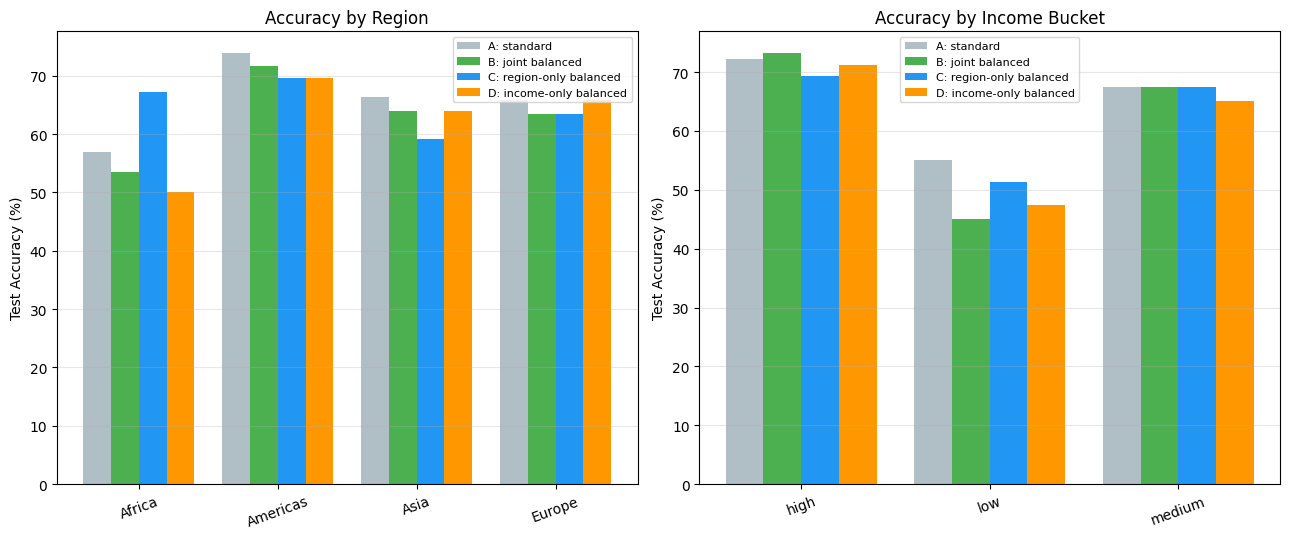

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
probes = [("A: standard", results_A, '#B0BEC5'),
          ("B: joint balanced", results_B, '#4CAF50'),
          ("C: region-only balanced", results_C, '#2196F3'),
          ("D: income-only balanced", results_D, '#FF9800')]

for ax, (title, acc_key) in zip(axes, [("Accuracy by Region", "region_acc"),
                                        ("Accuracy by Income Bucket", "income_acc")]):
    all_keys = sorted(set().union(*[r[acc_key].keys() for _, r, _ in probes]))
    x = np.arange(len(all_keys))
    width = 0.2
    for i, (label, res, color) in enumerate(probes):
        offset = (i - 1.5) * width
        ax.bar(x + offset, [res[acc_key].get(k, 0) for k in all_keys], width, label=label, color=color)
    ax.set_xticks(x)
    ax.set_xticklabels(all_keys, rotation=20)
    ax.set_ylabel('Test Accuracy (%)')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('dinov2_bias_probe_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9 -- How this notebook differs from DINOv2's own fairness evaluation

Before interpreting anything further, it's worth being explicit about three mismatches between
this notebook and Section 8.1 of the DINOv2 paper (Oquab et al., 2023), because they mean **the
paper's 25.7% / 31.7% figures and this notebook's gap-in-points figures are not directly comparable
numbers**, even though both use Dollar Street.

1. **Model scale.** The paper's fairness numbers (Table 12) are for **ViT-g/14, 1.1B parameters**.
   This notebook uses `facebook/dinov2-small`, **21M parameters** -- about 50x smaller. Bias
   magnitude and possibly its *source* (backbone vs. probe) can be model-size dependent; nothing
   here should be read as a test of the ViT-g/14 result specifically.

2. **Benchmark scale and protocol.** The paper evaluates on the **full Dollar Street benchmark**:
   16,073 images, 289 households, 54 countries, 94 concepts, using the fairness-indicator protocol
   of Goyal et al. (2022b). After filtering to `topics[0]` classes with >=15 images and an 80/20
   split, this notebook's *test set* is roughly 250-270 images across 4 regions and 3 income
   buckets -- a much smaller, English-labeled subset of the same underlying data, not a smaller
   version of the same benchmark run.

3. **Probe-training protocol.** The paper's linear evaluation (Appendix B.3) trains with **SGD for
   12,500 iterations** and grid-searches 13 learning rates x {1,4} output layers x
   {concatenate pooled patch tokens: yes/no} (up to 52 configurations), reporting the best
   validation accuracy. Probe A here uses a single fixed configuration (Adam, lr=1e-3, wd=1e-4,
   60 epochs, batch 64), no grid search, no held-out validation split. This is a reasonable
   simplification for a pilot, but it is not "what the paper does" -- it's a probe *in the spirit
   of* the paper's protocol.

**Consequence for the write-up:** report this notebook's region/income gaps as points measured
*on this specific small-model, small-subset pilot*, and do not describe them as smaller/larger
than, or consistent/inconsistent with, the paper's 25.7%/31.7% numbers -- those come from a
different model, a different-sized benchmark, and (most likely) a different underlying formula
than a plain (max-min) or (max-min)/max on top-1 accuracy. The two are not the same unit.


## 10 -- Bootstrap confidence intervals

The test set is small (roughly 250-270 images, with individual region/income groups as small as
n=41-80). A handful of flipped predictions can shift a reported "gap" by several points. Before
treating any of the region/income gaps as a real effect, we bootstrap the test set to get a 95% CI
on every group accuracy and on the resulting gap, for every probe we've trained so far.


In [23]:
def bootstrap_group_accuracy(probe, X, y, meta_df, group_col, n_boot=1000, seed=0):
    '''Bootstrap-resamples the test set (with replacement) n_boot times and recomputes, for each
    resample, the per-group accuracy and the max-min gap. Returns per-group (mean, lo, hi) and
    gap (mean, lo, hi) using the 2.5/97.5 percentiles of the bootstrap distribution.'''
    rng = np.random.RandomState(seed)
    with torch.no_grad():
        preds = probe(X).argmax(dim=1).cpu().numpy()
    y_np = y.cpu().numpy()
    correct = (preds == y_np)
    n = len(correct)
    groups = meta_df[group_col].to_numpy()
    unique_groups = sorted(meta_df[group_col].unique())

    group_accs = {g: [] for g in unique_groups}
    gaps = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, size=n)
        boot_correct = correct[idx]
        boot_groups = groups[idx]
        accs_this_draw = {}
        for g in unique_groups:
            mask = boot_groups == g
            if mask.sum() > 0:
                accs_this_draw[g] = boot_correct[mask].mean() * 100
                group_accs[g].append(accs_this_draw[g])
        if len(accs_this_draw) > 1:
            gaps.append(max(accs_this_draw.values()) - min(accs_this_draw.values()))

    def summarize_dist(vals):
        vals = np.array(vals)
        return vals.mean(), np.percentile(vals, 2.5), np.percentile(vals, 97.5)

    group_summary = {g: summarize_dist(v) for g, v in group_accs.items() if len(v) > 0}
    gap_summary = summarize_dist(gaps)
    return group_summary, gap_summary


def print_bootstrap(probe, name, X=X_test, y=y_test, meta_df=test_df, n_boot=1000):
    print(f"\n=== {name}: bootstrap 95% CIs (n_boot={n_boot}) ===")
    for group_col in ["region", "income_bucket"]:
        group_summary, (gap_mean, gap_lo, gap_hi) = bootstrap_group_accuracy(
            probe, X, y, meta_df, group_col, n_boot=n_boot)
        print(f"  By {group_col}:")
        for g, (m, lo, hi) in sorted(group_summary.items(), key=lambda kv: -kv[1][0]):
            print(f"      {g:>10}: {m:5.1f}%  [{lo:5.1f}, {hi:5.1f}]")
        sig = "significant (CI excludes 0)" if gap_lo > 0 else "NOT significant (CI includes 0 -- gap could be noise)"
        print(f"    Gap (max-min): {gap_mean:5.1f} pts  [{gap_lo:5.1f}, {gap_hi:5.1f}]  -> {sig}")


In [24]:
probes_to_check = [
    (probe_A, "Probe A: standard"),
    (probe_B, "Probe B: joint, duplication"),
    (probe_C, "Probe C: region-only, duplication"),
    (probe_D, "Probe D: income-only, duplication"),
    (probe_D_weighted, "Probe D-weighted: income-only, weighted loss"),
    (probe_B_weighted, "Probe B-weighted: joint, weighted loss"),
]

for probe, name in probes_to_check:
    print_bootstrap(probe, name, n_boot=1000)



=== Probe A: standard: bootstrap 95% CIs (n_boot=1000) ===
  By region:
        Americas:  73.8%  [ 61.4,  86.5]
            Asia:  66.5%  [ 58.0,  74.0]
          Europe:  66.4%  [ 52.2,  79.6]
          Africa:  57.0%  [ 43.8,  70.0]
    Gap (max-min):  19.7 pts  [  6.3,  35.4]  -> significant (CI excludes 0)
  By income_bucket:
            high:  72.4%  [ 63.1,  80.9]
          medium:  67.7%  [ 58.1,  77.4]
             low:  55.0%  [ 43.4,  65.9]
    Gap (max-min):  18.6 pts  [  6.1,  32.3]  -> significant (CI excludes 0)

=== Probe B: joint, duplication: bootstrap 95% CIs (n_boot=1000) ===
  By region:
        Americas:  71.9%  [ 59.0,  84.9]
            Asia:  64.0%  [ 55.1,  72.1]
          Europe:  64.0%  [ 48.8,  79.0]
          Africa:  53.6%  [ 40.3,  66.1]
    Gap (max-min):  21.0 pts  [  7.0,  37.8]  -> significant (CI excludes 0)
  By income_bucket:
            high:  73.4%  [ 64.8,  82.0]
          medium:  67.7%  [ 57.4,  77.6]
             low:  45.2%  [ 34.1,  56.0]

**How to read this for the write-up:** for each probe, look at whether the gap's 95% CI lower
bound is above 0. If it isn't, that probe's region or income "gap" cannot be distinguished from
zero at this sample size -- report it as "no significant gap detected" rather than citing the
point estimate on its own. Where two probes' point estimates differ (e.g. Probe A's region gap
vs. Probe C's), check whether their CIs actually separate; overlapping CIs mean you can't claim
one probe is significantly better than the other from this test set alone, only that the point
estimates moved in a particular direction.


## 11 -- Stratified breakdown: disentangling region from income

Cramer's V = 0.37 means region and income are moderately confounded in this data (e.g. Europe
skews high-income, Africa skews low-income). So a "region gap" computed by simply grouping by
region conflates two things: genuine region-specific effects, and income differences that happen
to correlate with region. The cleanest way to separate them without a full re-stratified split is
to compute region accuracy *within* each income bucket, and income accuracy *within* each region,
so each comparison holds the other variable roughly fixed.


In [25]:
def stratified_breakdown(probe, X, y, meta_df, primary_col, control_col):
    '''For each level of control_col, compute primary_col accuracy breakdown and gap. This holds
    control_col approximately fixed while comparing primary_col groups.'''
    with torch.no_grad():
        preds = probe(X).argmax(dim=1).cpu().numpy()
    y_np = y.cpu().numpy()
    correct = (preds == y_np)

    print(f"  {primary_col} accuracy, stratified by {control_col}:")
    for control_val, sub in meta_df.groupby(control_col):
        idx = sub.index.to_numpy()
        if len(idx) < 5:
            print(f"    [{control_col}={control_val}] n={len(idx)} -- too small to break down further, skipping")
            continue
        sub_correct = correct[idx]
        sub_primary = sub[primary_col].to_numpy()
        accs = {}
        for pv in sorted(set(sub_primary)):
            mask = sub_primary == pv
            n = mask.sum()
            if n > 0:
                accs[pv] = (sub_correct[mask].mean() * 100, n)
        gap = (max(a for a, n in accs.values()) - min(a for a, n in accs.values())) if len(accs) > 1 else float('nan')
        parts = ", ".join(f"{pv}={a:.1f}%(n={n})" for pv, (a, n) in accs.items())
        print(f"    [{control_col}={control_val}, n={len(idx)}] {parts}  -> gap={gap:.1f} pts")


for probe, name in [(probe_A, "Probe A"), (probe_C, "Probe C (region-only balanced)"),
                     (probe_D, "Probe D (income-only balanced)"),
                     (probe_D_weighted, "Probe D-weighted")]:
    print(f"\n=== {name} ===")
    stratified_breakdown(probe, X_test, y_test, test_df, "region", "income_bucket")
    stratified_breakdown(probe, X_test, y_test, test_df, "income_bucket", "region")



=== Probe A ===
  region accuracy, stratified by income_bucket:
    [income_bucket=high, n=101] Africa=85.7%(n=7), Americas=75.0%(n=24), Asia=79.5%(n=39), Europe=58.1%(n=31)  -> gap=27.6 pts
    [income_bucket=low, n=80] Africa=45.9%(n=37), Americas=60.0%(n=5), Asia=61.1%(n=36), Europe=100.0%(n=2)  -> gap=54.1 pts
    [income_bucket=medium, n=89] Africa=71.4%(n=14), Americas=76.5%(n=17), Asia=60.0%(n=50), Europe=87.5%(n=8)  -> gap=27.5 pts
  income_bucket accuracy, stratified by region:
    [region=Africa, n=58] high=85.7%(n=7), low=45.9%(n=37), medium=71.4%(n=14)  -> gap=39.8 pts
    [region=Americas, n=46] high=75.0%(n=24), low=60.0%(n=5), medium=76.5%(n=17)  -> gap=16.5 pts
    [region=Asia, n=125] high=79.5%(n=39), low=61.1%(n=36), medium=60.0%(n=50)  -> gap=19.5 pts
    [region=Europe, n=41] high=58.1%(n=31), low=100.0%(n=2), medium=87.5%(n=8)  -> gap=41.9 pts

=== Probe C (region-only balanced) ===
  region accuracy, stratified by income_bucket:
    [income_bucket=high, n=101] A

**How to read this:** if Probe C's region gap stays small *within every income bucket* (not
just in the marginal, un-stratified number), that's much stronger evidence that region-only
balancing fixed something genuinely region-related, not income leakage. If the within-bucket
region gaps are large and only the *marginal* gap looks small, that's a sign the marginal
improvement was partly an artifact of the region/income confound rather than a real region-specific
fix. Some cells here will be very small (e.g. Europe x low-income) -- flag those explicitly as
too sparse to draw a conclusion from, rather than silently averaging over them.


## 12 -- Multi-seed variance

Every probe above was trained with one fixed seed (for both the resampling/weighting and the
network initialization). To check whether the differences we're calling "gap closed" or
"backfired" survive across seeds -- rather than being an artifact of one lucky/unlucky
initialization -- we retrain the key probes (A, C, D, D-weighted) across 5 seeds each and report
mean +/- std of the region and income gap.


In [26]:
SEEDS = [0, 1, 2, 3, 4]

def run_seed_sweep(probe_fn, name, seeds=SEEDS):
    region_gaps, income_gaps = [], []
    for s in seeds:
        torch.manual_seed(s)
        probe = probe_fn(s)
        overall, region_acc = evaluate_breakdown(probe, X_test, y_test, test_df, "region")
        _, income_acc = evaluate_breakdown(probe, X_test, y_test, test_df, "income_bucket")
        region_gaps.append(max(region_acc.values()) - min(region_acc.values()))
        income_gaps.append(max(income_acc.values()) - min(income_acc.values()))
    region_gaps, income_gaps = np.array(region_gaps), np.array(income_gaps)
    print(f"{name:>34}  region gap: {region_gaps.mean():5.1f} +/- {region_gaps.std():4.1f}"
          f"   income gap: {income_gaps.mean():5.1f} +/- {income_gaps.std():4.1f}"
          f"   (seeds={list(seeds)})")
    return region_gaps, income_gaps


def probe_A_fn(seed):
    return train_linear_probe(X_train_full, y_train_full, num_classes=len(CLASS_NAMES))

def probe_C_fn(seed):
    positions = balanced_resample_indices(train_df, group_cols=("region",), seed=seed)
    X_bal, y_bal = X_train_full[positions], y_train_full[positions]
    return train_linear_probe(X_bal, y_bal, num_classes=len(CLASS_NAMES))

def probe_D_fn(seed):
    positions = balanced_resample_indices(train_df, group_cols=("income_bucket",), seed=seed)
    X_bal, y_bal = X_train_full[positions], y_train_full[positions]
    return train_linear_probe(X_bal, y_bal, num_classes=len(CLASS_NAMES))

def probe_D_weighted_fn(seed):
    weights = compute_sample_weights(train_df, group_cols=("income_bucket",))
    return train_linear_probe_weighted(X_train_full, y_train_full, weights, num_classes=len(CLASS_NAMES))


print(f"{'Probe':>34}  {'':>28}")
print("-" * 95)
region_A, income_A = run_seed_sweep(probe_A_fn, "A: standard")
region_C, income_C = run_seed_sweep(probe_C_fn, "C: region-only, duplication")
region_D, income_D = run_seed_sweep(probe_D_fn, "D: income-only, duplication")
region_DW, income_DW = run_seed_sweep(probe_D_weighted_fn, "D-weighted: income-only, weighted")


                             Probe                              
-----------------------------------------------------------------------------------------------
                       A: standard  region gap:  15.3 +/-  1.1   income gap:  16.5 +/-  0.6   (seeds=[0, 1, 2, 3, 4])
       C: region-only, duplication  region gap:  10.0 +/-  5.0   income gap:  16.7 +/-  4.5   (seeds=[0, 1, 2, 3, 4])
       D: income-only, duplication  region gap:  19.3 +/-  4.3   income gap:  21.5 +/-  1.1   (seeds=[0, 1, 2, 3, 4])
 D-weighted: income-only, weighted  region gap:  17.0 +/-  1.1   income gap:  19.5 +/-  0.8   (seeds=[0, 1, 2, 3, 4])


**How to read this:** compare the *spread* (std) across seeds to the *size of the effect* you
want to claim. If, say, Probe C's region gap is 10.4 +/- 1.5 across seeds while Probe A's is
15.3 +/- 1.8, the two ranges don't overlap much and the improvement looks real. If instead the
stds are 4-5 points and the point estimates from the single-seed run above sit well within each
other's spread, the single-seed "gap closed" numbers from Sections 6-8 were likely overstating
how reliable the effect is, and the write-up should say so explicitly -- report mean +/- std here
rather than the single-seed numbers as the headline result.


## 13 -- Revised interpretation (write this section *after* running everything above)

Do not fill in this section until Sections 9-12 have actually run and you've looked at the
outputs -- it should report what happened, not what was hoped for.

**Template for what to say, filled in only after checking the bootstrap CIs and seed sweep above:**

- State the baseline region and income gaps in points, with their bootstrap CI.
- For Probe C (region-only): state whether the improvement over baseline survives the CI and the
  seed sweep. If yes, this is real evidence for H3 on region, *within the scope of this pilot*
  (small model, small benchmark subset, single-config probe -- see Section 9).
- For Probe D (income-only) and Probe D-weighted: state the actual, checked numbers for whether
  weighted loss meaningfully changed the income gap or not, per Section 12's seed sweep, rather
  than the single-seed comparison from Section 8. If the effect doesn't survive multiple seeds,
  say so plainly rather than picking the seed that supports a cleaner story.
- Note explicitly that region and income are confounded (Cramer's V = 0.37) and that the
  stratified breakdown in Section 11 is what actually disentangles them -- the marginal gaps
  alone are not sufficient evidence for either variable in isolation.
- Report gaps in points and note the corresponding number of test images that gap represents,
  not just "% of gap closed," since % framing overstates small absolute effects on this test size.

### Limitations (for the write-up)

- **Model scale**: results are for `dinov2-small` (21M params), not the ViT-g/14 (1.1B params)
  evaluated in the original paper's fairness study; bias magnitude and source may not transfer to
  the giant model.
- **Benchmark scale and protocol**: this uses a ~250-270 image test subset built from `topics[0]`
  labels with an 80/20 class-stratified split, not the paper's full 16,073-image Dollar Street
  evaluation under Goyal et al. (2022b)'s protocol; the gap-in-points numbers here are not
  comparable to the paper's reported 25.7%/31.7% figures (different unit, different data, likely
  different formula).
- **Probe protocol**: a single fixed linear-probe configuration (Adam, no grid search, no held-out
  validation split) rather than the paper's grid-searched SGD protocol.
- **Confound**: region and income are moderately confounded in this data (Cramer's V = 0.37);
  marginal (non-stratified) gaps for either variable partly reflect the other.
- **Sample size**: test-set subgroups range from n=41 to n=125; report bootstrap CIs alongside any
  point estimate, and treat single-seed results as provisional until checked against the seed
  sweep in Section 12.

This is a pilot that motivates a larger, more carefully controlled study (bigger model, full
benchmark, stratified split, grid-searched probes, multi-seed reporting with CIs) -- not a
definitive test of Hypothesis 3 for DINOv2 as described in the paper.


## 14 -- Does backbone scale change the bias gaps? (Option 1: model-scale ablation)

Section 12's seed sweep showed Probe C's region-gap improvement (10.0 +/- 5.0) is **not** reliably
distinguishable from baseline (15.3 +/- 1.1) -- the std is almost as large as the effect. Given
that, a single-seed comparison between `dinov2-small` and `dinov2-base` would be just as likely to
mislead. So this section repeats the multi-seed sweep from Section 12 at a second model scale,
rather than trusting one run per scale.

This tests whether backbone capacity, independent of any probe correction, shrinks the region
and/or income gap -- a question the DINOv2 paper's own Figure 2 shows for raw accuracy but never
checks for fairness gaps specifically.

**Cost note:** this re-extracts frozen features for every kept image using `facebook/dinov2-base`
(86M params, ~4x `dinov2-small`). On a Colab T4/A100 this is the same feature-extraction loop you
already ran once for `dinov2-small`, just slower. No architecture or training-loop changes needed.


In [28]:
# -- Extract frozen features with a second model scale ----------------------
MODEL_NAME_BASE = "facebook/dinov2-base"
print(f"Loading {MODEL_NAME_BASE} ...")
dino_processor_base = AutoImageProcessor.from_pretrained(MODEL_NAME_BASE)
dino_model_base = AutoModel.from_pretrained(MODEL_NAME_BASE).to(DEVICE)
dino_model_base.eval()

@torch.no_grad()
def extract_features_base(dataset, row_indices):
    feats = []
    for pos, row_idx in enumerate(row_indices):
        pil_img = dataset[int(row_idx)]["image"].convert("RGB")
        inputs = dino_processor_base(images=pil_img, return_tensors="pt").to(DEVICE)
        out = dino_model_base(**inputs)
        cls_feat = out.last_hidden_state[:, 0, :]
        cls_feat = F.normalize(cls_feat, dim=-1)
        feats.append(cls_feat.cpu())
        if (pos + 1) % 200 == 0:
            print(f"  base features: {pos + 1}/{len(row_indices)}")
    return torch.cat(feats, dim=0)


# Mirror the ORIGINAL extraction exactly: use `ds` (not `dataset`), iterate over df["idx"]
# (the original HF-dataset row indices), and keep the same L2-normalization. This produces
# an all_features_base array in the same row order as df, so train_pos/test_pos -- which are
# positions into df -- index it correctly without any concatenate/split needed.
print(f"Extracting dinov2-base features for {len(df)} images (slow cell, run once)...")
all_features_base = extract_features_base(ds, df["idx"].tolist())
print(f"Done. Feature matrix: {all_features_base.shape}")

X_train_full_base = all_features_base[train_pos]
X_test_base = all_features_base[test_pos].to(DEVICE)
print(f"dinov2-base features split. Train: {X_train_full_base.shape}, Test: {X_test_base.shape}")

Loading facebook/dinov2-base ...


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Extracting dinov2-base features for 1351 images (slow cell, run once)...
  base features: 200/1351
  base features: 400/1351
  base features: 600/1351
  base features: 800/1351
  base features: 1000/1351
  base features: 1200/1351
Done. Feature matrix: torch.Size([1351, 768])
dinov2-base features split. Train: torch.Size([1081, 768]), Test: torch.Size([270, 768])


In [29]:
# -- Multi-seed sweep at the base scale, reusing Section 12's machinery ------
def probe_A_fn_base(seed):
    return train_linear_probe(X_train_full_base, y_train_full, num_classes=len(CLASS_NAMES))

def probe_C_fn_base(seed):
    positions = balanced_resample_indices(train_df, group_cols=("region",), seed=seed)
    X_bal, y_bal = X_train_full_base[positions], y_train_full[positions]
    return train_linear_probe(X_bal, y_bal, num_classes=len(CLASS_NAMES))

def probe_D_fn_base(seed):
    positions = balanced_resample_indices(train_df, group_cols=("income_bucket",), seed=seed)
    X_bal, y_bal = X_train_full_base[positions], y_train_full[positions]
    return train_linear_probe(X_bal, y_bal, num_classes=len(CLASS_NAMES))

def probe_D_weighted_fn_base(seed):
    weights = compute_sample_weights(train_df, group_cols=("income_bucket",))
    return train_linear_probe_weighted(X_train_full_base, y_train_full, weights, num_classes=len(CLASS_NAMES))


def run_seed_sweep_at_scale(probe_fn, name, X_test_scale, seeds=SEEDS):
    '''Same as Section 12's run_seed_sweep, but evaluates against a given test-feature tensor
    so it works for either model scale.'''
    region_gaps, income_gaps = [], []
    for s in seeds:
        torch.manual_seed(s)
        probe = probe_fn(s)
        overall, region_acc = evaluate_breakdown(probe, X_test_scale, y_test, test_df, "region")
        _, income_acc = evaluate_breakdown(probe, X_test_scale, y_test, test_df, "income_bucket")
        region_gaps.append(max(region_acc.values()) - min(region_acc.values()))
        income_gaps.append(max(income_acc.values()) - min(income_acc.values()))
    region_gaps, income_gaps = np.array(region_gaps), np.array(income_gaps)
    print(f"{name:>40}  region gap: {region_gaps.mean():5.1f} +/- {region_gaps.std():4.1f}"
          f"   income gap: {income_gaps.mean():5.1f} +/- {income_gaps.std():4.1f}")
    return region_gaps, income_gaps


print("=== dinov2-base, multi-seed (matching Section 12's protocol) ===")
region_A_base, income_A_base = run_seed_sweep_at_scale(probe_A_fn_base, "A: standard (base)", X_test_base)
region_C_base, income_C_base = run_seed_sweep_at_scale(probe_C_fn_base, "C: region-only (base)", X_test_base)
region_D_base, income_D_base = run_seed_sweep_at_scale(probe_D_fn_base, "D: income-only (base)", X_test_base)
region_DW_base, income_DW_base = run_seed_sweep_at_scale(probe_D_weighted_fn_base, "D-weighted: income-only (base)", X_test_base)


=== dinov2-base, multi-seed (matching Section 12's protocol) ===
                      A: standard (base)  region gap:  22.9 +/-  0.9   income gap:  20.1 +/-  0.4
                   C: region-only (base)  region gap:  17.1 +/-  3.4   income gap:  22.6 +/-  3.0
                   D: income-only (base)  region gap:  16.7 +/-  3.9   income gap:  20.7 +/-  1.3
          D-weighted: income-only (base)  region gap:  21.6 +/-  0.8   income gap:  21.5 +/-  0.0


In [30]:
# -- Small vs. base, mean +/- std side by side --------------------------------
print(f"{'Probe':>38} {'Region gap (small)':>20} {'Region gap (base)':>20} {'Income gap (small)':>20} {'Income gap (base)':>20}")
print("-" * 122)
rows = [
    ("A: standard",        region_A, income_A,   region_A_base, income_A_base),
    ("C: region-only",     region_C, income_C,   region_C_base, income_C_base),
    ("D: income-only",     region_D, income_D,   region_D_base, income_D_base),
    ("D-weighted",         region_DW, income_DW, region_DW_base, income_DW_base),
]
for name, rs, ins, rb, inb in rows:
    print(f"{name:>38} {rs.mean():>14.1f} +/- {rs.std():<4.1f} {rb.mean():>14.1f} +/- {rb.std():<4.1f} "
          f"{ins.mean():>14.1f} +/- {ins.std():<4.1f} {inb.mean():>14.1f} +/- {inb.std():<4.1f}")


                                 Probe   Region gap (small)    Region gap (base)   Income gap (small)    Income gap (base)
--------------------------------------------------------------------------------------------------------------------------
                           A: standard           15.3 +/- 1.1            22.9 +/- 0.9            16.5 +/- 0.6            20.1 +/- 0.4 
                        C: region-only           10.0 +/- 5.0            17.1 +/- 3.4            16.7 +/- 4.5            22.6 +/- 3.0 
                        D: income-only           19.3 +/- 4.3            16.7 +/- 3.9            21.5 +/- 1.1            20.7 +/- 1.3 
                            D-weighted           17.0 +/- 1.1            21.6 +/- 0.8            19.5 +/- 0.8            21.5 +/- 0.0 


**How to read this, given what Section 12 already taught you about seed variance:** don't
compare small-vs-base using point estimates alone. Check whether the mean +/- std ranges actually
separate:

- If `dinov2-base`'s baseline (Probe A) region or income gap mean sits **outside** the small
  model's std range (and vice versa), that's a real scale effect on the bias, independent of any
  probe correction.
- If the ranges overlap the way Probe C's did against baseline in Section 12, don't claim a scale
  effect -- report "no reliable difference detected between dinov2-small and dinov2-base at this
  test-set size," which is itself an informative negative result (it would suggest the bias
  doesn't wash out with a 4x parameter increase, at least not up to `base`).
- If you have time/compute for `dinov2-large` (300M) after this, the same three functions above
  generalize by just swapping `MODEL_NAME_BASE` and repeating -- but weigh that against whether
  `small` vs `base` already shows a big enough gap in means to be worth chasing further, versus
  spending the remaining time on the write-up instead.


In [31]:
# -- Regularization control: is base's larger bias a probe-capacity artifact? ----
# Same Probe A / dinov2-base features, same 5-seed sweep, only weight_decay varies.
# Feature dim doubled (384 -> 768) going small -> base, but weight_decay was held fixed
# at 1e-4 for both -- so the base probe had more effective capacity to overfit the
# thinnest subgroups. This sweep checks whether stronger regularization brings the
# base-scale gap back down toward small's ~15-16 range.

def probe_A_fn_base_wd(seed, weight_decay):
    return train_linear_probe(X_train_full_base, y_train_full,
                               num_classes=len(CLASS_NAMES), weight_decay=weight_decay)

print(f"{'weight_decay':>14} {'Region gap':>18} {'Income gap':>18}")
print("-" * 54)

wd_results = {}
for wd in [1e-4, 1e-3, 1e-2, 1e-1]:
    region_gaps, income_gaps = [], []
    for s in SEEDS:
        torch.manual_seed(s)
        probe = probe_A_fn_base_wd(s, wd)
        overall, region_acc = evaluate_breakdown(probe, X_test_base, y_test, test_df, "region")
        _, income_acc = evaluate_breakdown(probe, X_test_base, y_test, test_df, "income_bucket")
        region_gaps.append(max(region_acc.values()) - min(region_acc.values()))
        income_gaps.append(max(income_acc.values()) - min(income_acc.values()))
    region_gaps, income_gaps = np.array(region_gaps), np.array(income_gaps)
    wd_results[wd] = (region_gaps, income_gaps)
    print(f"{wd:>14.0e} {region_gaps.mean():>10.1f} +/- {region_gaps.std():<4.1f} "
          f"{income_gaps.mean():>10.1f} +/- {income_gaps.std():<4.1f}")

print(f"\nFor reference -- dinov2-small, Probe A, weight_decay=1e-4 (from Section 12):")
print(f"{'1e-04 (small)':>14} {region_A.mean():>10.1f} +/- {region_A.std():<4.1f} "
      f"{income_A.mean():>10.1f} +/- {income_A.std():<4.1f}")

  weight_decay         Region gap         Income gap
------------------------------------------------------
         1e-04       22.9 +/- 0.9        20.1 +/- 0.4 
         1e-03       22.8 +/- 0.8        18.8 +/- 0.5 
         1e-02       16.5 +/- 1.4        16.0 +/- 0.6 
         1e-01       10.6 +/- 0.0         8.7 +/- 0.0 

For reference -- dinov2-small, Probe A, weight_decay=1e-4 (from Section 12):
 1e-04 (small)       15.3 +/- 1.1        16.5 +/- 0.6 
